# 04 - DDIM and Classifier-Free Guidance (2D toy)

This notebook builds a **class-conditional** diffusion model on a tiny 2D dataset
(`sklearn.make_moons`, 2 classes) and then demonstrates two practical sampling ideas:

- **(A) DDIM vs DDPM sampling** - deterministic, non-Markovian sampling that needs far
  fewer steps than ancestral DDPM.
- **(B) Classifier-free guidance (CFG)** - steer samples toward a class by extrapolating
  away from the unconditional prediction.

Everything runs on CPU with torch in well under ~120s. We use only
numpy / matplotlib / scikit-learn / torch.

### Why a 2D toy?
A 2D point cloud lets us *see* the full data distribution in a scatter plot. There is no
"is this image good?" guesswork - if the model captures the two crescent moons, we can
literally look at it. That makes the DDIM-vs-DDPM and the guidance-strength comparisons
honest and immediate.

## Setup and seeding

We seed Python, numpy, and torch so every run is reproducible. The model is a small MLP,
so CPU is plenty.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

SEED = 0


def seed_everything(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_everything()
torch.set_num_threads(2)  # keep CPU usage modest and deterministic-ish
DEVICE = torch.device("cpu")
print("torch", torch.__version__, "| device", DEVICE)

torch 2.12.0+cpu | device cpu


## The data: two moons, two classes

`make_moons` returns points on two interleaving half-circles plus a label saying which
moon each point belongs to. We treat that label as the **class** for class-conditional
generation. We standardize the cloud so coordinates are roughly unit-scale, which keeps the
noise schedule well-behaved.

X (4000, 2) | classes [0, 1]


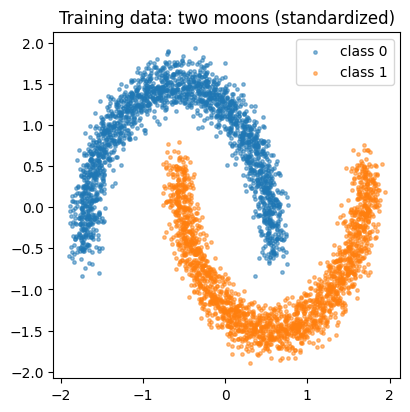

In [2]:
N = 4000
X_np, y_np = make_moons(n_samples=N, noise=0.08, random_state=SEED)

# Standardize to roughly zero-mean / unit-std (per coordinate).
X_mean = X_np.mean(axis=0, keepdims=True)
X_std = X_np.std(axis=0, keepdims=True)
X_np = (X_np - X_mean) / X_std

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

print("X", tuple(X.shape), "| classes", torch.unique(y).tolist())

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for c in [0, 1]:
    m = (y_np == c)
    ax.scatter(X_np[m, 0], X_np[m, 1], s=6, alpha=0.5, label="class %d" % c)
ax.set_title("Training data: two moons (standardized)")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.show()

## Forward (noising) process

We use a **linear beta schedule** with `T = 200` discrete timesteps. Define
`alpha_t = 1 - beta_t` and the cumulative product `alpha_bar_t = prod_{s<=t} alpha_s`.

The closed-form forward marginal lets us jump to any timestep in one shot:

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon, \qquad \epsilon \sim \mathcal N(0, I).$$

We precompute the schedule tensors once.

In [3]:
T = 200
beta_start, beta_end = 1e-4, 0.02
betas = torch.linspace(beta_start, beta_end, T)            # (T,)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)                  # (T,)

# Handy roots for the forward marginal.
sqrt_ab = torch.sqrt(alpha_bars)
sqrt_one_minus_ab = torch.sqrt(1.0 - alpha_bars)


def q_sample(x0, t, noise):
    # x0: (B,2), t: (B,) long indices into the schedule, noise: (B,2)
    a = sqrt_ab[t].unsqueeze(1)
    b = sqrt_one_minus_ab[t].unsqueeze(1)
    return a * x0 + b * noise


print("betas[:3]", betas[:3].tolist())
print("alpha_bars[0], alpha_bars[-1]:", float(alpha_bars[0]), float(alpha_bars[-1]))

betas[:3] [9.999999747378752e-05, 0.00019999999494757503, 0.00029999998514540493]
alpha_bars[0], alpha_bars[-1]: 0.9998999834060669 0.1321827620267868


## The model: class-conditional epsilon predictor with label dropout

The network predicts the noise `epsilon` that was added, given the noisy point `x_t`, the
timestep `t`, and the class label.

Two embeddings feed the MLP:

- a **sinusoidal time embedding** of `t` (the standard transformer-style positional code), and
- a learned **class embedding** with an extra **null token** for the *unconditional* case.

**Label dropout** is the key trick for classifier-free guidance: during training we randomly
replace the real class with the null token ~15% of the time. The single network thus learns
*both* the conditional model `eps(x, t, class)` and the unconditional model `eps(x, t, null)`.
At sampling time we query both and combine them - no separate classifier needed.

In [4]:
def timestep_embedding(t, dim):
    # t: (B,) long -> (B, dim) sinusoidal embedding
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(half, dtype=torch.float32) / max(half - 1, 1)
    )
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)  # (B, half)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros(emb.shape[0], 1)], dim=1)
    return emb


NUM_CLASSES = 2
NULL_TOKEN = NUM_CLASSES  # index 2 == "no class" / unconditional


class EpsMLP(nn.Module):
    def __init__(self, t_dim=32, c_dim=32, hidden=128):
        super().__init__()
        self.t_dim = t_dim
        self.class_emb = nn.Embedding(NUM_CLASSES + 1, c_dim)  # +1 for null token
        self.net = nn.Sequential(
            nn.Linear(2 + t_dim + c_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t, c):
        te = timestep_embedding(t, self.t_dim)   # (B, t_dim)
        ce = self.class_emb(c)                    # (B, c_dim)
        h = torch.cat([x, te, ce], dim=1)
        return self.net(h)


model = EpsMLP().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print("model params:", n_params)

model params: 41954


## Training loop

Standard DDPM denoising objective: sample a random timestep `t` per example, noise the data
to `x_t`, and train the network to predict the noise via MSE. Label dropout is applied each
step by overwriting ~15% of labels with the null token.

We run ~2500 steps with a fixed batch; on CPU this is a few seconds.

In [5]:
STEPS = 2500
BATCH = 512
P_DROP = 0.15  # label-dropout probability for classifier-free guidance

opt = torch.optim.Adam(model.parameters(), lr=2e-3)

seed_everything()  # reproducible minibatch + noise draws
model.train()
losses = []
for step in range(STEPS):
    idx = torch.randint(0, N, (BATCH,))
    x0 = X[idx]
    c = y[idx].clone()

    # Label dropout -> classifier-free guidance support.
    drop = torch.rand(BATCH) < P_DROP
    c[drop] = NULL_TOKEN

    t = torch.randint(0, T, (BATCH,))
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)

    pred = model(xt, t, c)
    loss = F.mse_loss(pred, noise)

    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

print("final loss (avg last 100): %.4f" % np.mean(losses[-100:]))

final loss (avg last 100): 0.4176


A quick loss curve - it should fall fast and then flatten. The exact floor does not
matter; we only need a model good enough to reproduce the two moons.

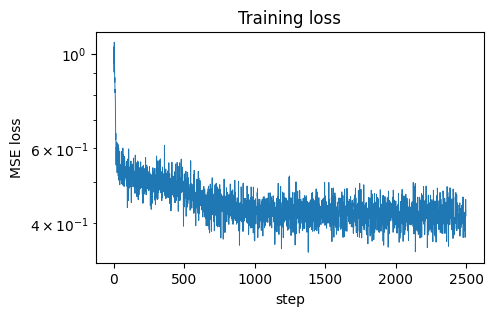

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(losses, lw=0.7)
ax.set_xlabel("step")
ax.set_ylabel("MSE loss")
ax.set_title("Training loss")
ax.set_yscale("log")
plt.show()

## (A) DDIM vs DDPM sampling

### DDPM ancestral sampling (the baseline)
DDPM reverses the chain one step at a time. Each reverse step is **stochastic** - it adds
fresh noise - and the process is **Markovian**, so to undo `T = 200` forward steps you take
200 reverse steps. Faithful, but slow.

### DDIM sampling (deterministic, non-Markovian, fewer steps)
DDIM (Song et al., 2020) keeps the *same trained model* but defines a **non-Markovian**
forward process that shares DDPM's marginals `q(x_t | x_0)`. The reverse update, with the
stochasticity knob `eta = 0`, becomes **deterministic**:

1. Predict the clean point from the current noisy point and the predicted noise:
   $$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta}{\sqrt{\bar\alpha_t}}.$$
2. Re-noise toward the *previous* timestep `t_prev` using the predicted noise as the
   "direction pointing to `x_t`":
   $$x_{t_{prev}} = \sqrt{\bar\alpha_{t_{prev}}}\,\hat x_0 + \sqrt{1-\bar\alpha_{t_{prev}}}\,\epsilon_\theta.$$

Because each step maps deterministically from `x_t` to `x_{t_prev}`, we can **skip
timesteps** - choose any subsequence of `[0..T-1]` - and still land on a coherent sample.
That is why DDIM produces good samples in 20-50 steps where DDPM wants ~200.

Below we implement both. We sample *unconditionally* here (null token) so the comparison is
purely about the sampler, not about guidance.

In [7]:
@torch.no_grad()
def ddpm_sample(model, n, c_value, steps=T):
    # Ancestral DDPM over the full schedule (steps == T). Stochastic.
    model.eval()
    x = torch.randn(n, 2)
    c = torch.full((n,), c_value, dtype=torch.long)
    for i in reversed(range(T)):
        t = torch.full((n,), i, dtype=torch.long)
        eps = model(x, t, c)
        alpha = alphas[i]
        alpha_bar = alpha_bars[i]
        beta = betas[i]
        # posterior mean
        coef = beta / torch.sqrt(1.0 - alpha_bar)
        mean = (1.0 / torch.sqrt(alpha)) * (x - coef * eps)
        if i > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta) * noise
        else:
            x = mean
    return x.numpy()


@torch.no_grad()
def ddim_sample(model, n, c_value, steps=50, eta=0.0):
    # Deterministic (eta=0) DDIM over a uniform sub-sequence of timesteps.
    model.eval()
    x = torch.randn(n, 2)
    c = torch.full((n,), c_value, dtype=torch.long)
    # Evenly spaced timesteps from high -> low, e.g. [199, ..., 0].
    ts = torch.linspace(T - 1, 0, steps).round().long().tolist()
    for j, i in enumerate(ts):
        t = torch.full((n,), i, dtype=torch.long)
        eps = model(x, t, c)
        ab_t = alpha_bars[i]
        # predicted x0
        x0_hat = (x - torch.sqrt(1.0 - ab_t) * eps) / torch.sqrt(ab_t)
        i_prev = ts[j + 1] if j + 1 < len(ts) else 0
        ab_prev = alpha_bars[i_prev] if i_prev > 0 else torch.tensor(1.0)
        # eta=0 -> deterministic; sigma term drops out
        sigma = eta * torch.sqrt((1 - ab_prev) / (1 - ab_t)) * torch.sqrt(1 - ab_t / ab_prev)
        dir_xt = torch.sqrt(torch.clamp(1.0 - ab_prev - sigma ** 2, min=0.0)) * eps
        x = torch.sqrt(ab_prev) * x0_hat + dir_xt
        if eta > 0 and i_prev > 0:
            x = x + sigma * torch.randn_like(x)
    return x.numpy()


print("samplers defined")

samplers defined


Now sample with each method (unconditional) and time them. We compare DDIM at 20 and
50 steps against DDPM at the full 200 steps. Watch the wall-clock numbers: DDIM at 20 steps
is roughly an order of magnitude cheaper in network evaluations.

In [8]:
import time

NS = 1500
results = {}
for name, fn, kw in [
    ("DDPM (200 steps)", ddpm_sample, {"steps": T}),
    ("DDIM (50 steps)", ddim_sample, {"steps": 50}),
    ("DDIM (20 steps)", ddim_sample, {"steps": 20}),
]:
    seed_everything()  # same starting noise across samplers for a fair look
    t0 = time.time()
    samp = fn(model, NS, NULL_TOKEN, **kw)
    dt = time.time() - t0
    results[name] = (samp, dt)
    print("%-18s -> %.3fs" % (name, dt))

DDPM (200 steps)   -> 0.277s
DDIM (50 steps)    -> 0.098s
DDIM (20 steps)    -> 0.023s


### Figure A: side-by-side scatter

Left to right: DDPM (200), DDIM (50), DDIM (20). The faint gray cloud behind each panel is
the real training data for reference. DDIM with 20 steps already recovers the two-moon shape;
50 steps tightens it; 200-step DDPM is the slow gold standard. The **step-count / speed
tradeoff** is the whole point - DDIM buys most of the quality at a fraction of the cost.

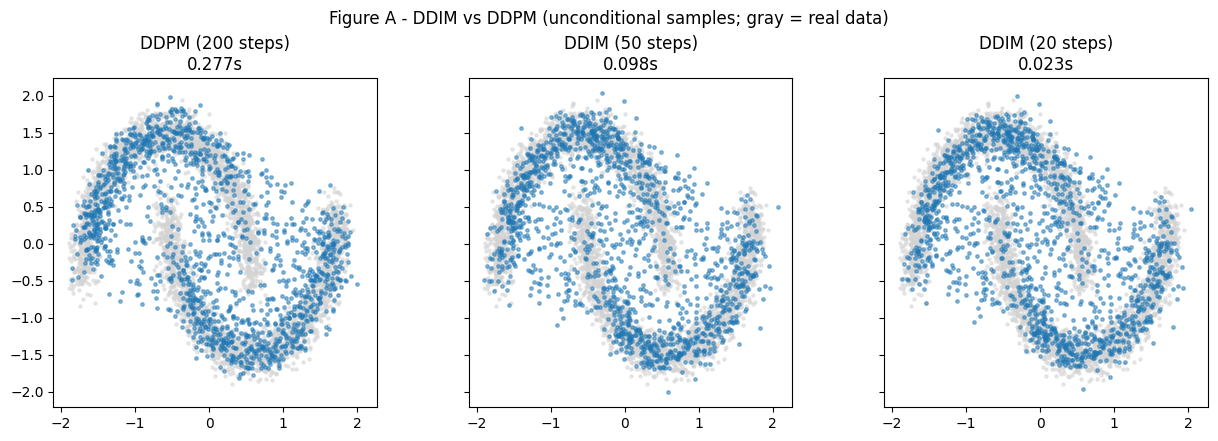

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharex=True, sharey=True)
order = ["DDPM (200 steps)", "DDIM (50 steps)", "DDIM (20 steps)"]
for ax, name in zip(axes, order):
    samp, dt = results[name]
    ax.scatter(X_np[:, 0], X_np[:, 1], s=5, c="lightgray", alpha=0.5)
    ax.scatter(samp[:, 0], samp[:, 1], s=6, c="tab:blue", alpha=0.5)
    ax.set_title("%s\n%.3fs" % (name, dt))
    ax.set_aspect("equal")
fig.suptitle("Figure A - DDIM vs DDPM (unconditional samples; gray = real data)")
plt.tight_layout()
plt.show()

## (B) Classifier-free guidance (CFG)

We trained one network that knows both the conditional and the unconditional predictions
(thanks to label dropout). Classifier-free guidance combines them at sampling time:

$$\tilde\epsilon = \epsilon_\theta(x,t,\varnothing) + w\,\big(\epsilon_\theta(x,t,c) - \epsilon_\theta(x,t,\varnothing)\big).$$

- `w = 0` collapses to the **unconditional** model (the class is ignored).
- `w = 1` is the plain **conditional** model.
- `w > 1` **extrapolates** past the conditional prediction, pushing samples deeper into the
  region the classifier would call class `c`. Higher `w` sharpens class separation but, pushed
  far enough, sacrifices diversity / fidelity.

We fold the CFG combination into a guided DDIM sampler (deterministic, fast) and sweep
`w in {0, 1, 3, 6}`, sampling each class.

In [10]:
@torch.no_grad()
def ddim_sample_cfg(model, n, c_value, w=1.0, steps=50):
    # Guided deterministic DDIM. Two forward passes per step: cond + uncond.
    model.eval()
    x = torch.randn(n, 2)
    c_cond = torch.full((n,), c_value, dtype=torch.long)
    c_null = torch.full((n,), NULL_TOKEN, dtype=torch.long)
    ts = torch.linspace(T - 1, 0, steps).round().long().tolist()
    for j, i in enumerate(ts):
        t = torch.full((n,), i, dtype=torch.long)
        eps_c = model(x, t, c_cond)
        eps_u = model(x, t, c_null)
        eps = eps_u + w * (eps_c - eps_u)   # CFG combination
        ab_t = alpha_bars[i]
        x0_hat = (x - torch.sqrt(1.0 - ab_t) * eps) / torch.sqrt(ab_t)
        i_prev = ts[j + 1] if j + 1 < len(ts) else 0
        ab_prev = alpha_bars[i_prev] if i_prev > 0 else torch.tensor(1.0)
        x = torch.sqrt(ab_prev) * x0_hat + torch.sqrt(torch.clamp(1.0 - ab_prev, min=0.0)) * eps
    return x.numpy()


print("CFG sampler defined")

CFG sampler defined


### Figure B: guidance-strength sweep

Each panel is one `w`. Within a panel we draw class 0 and class 1 separately so you can see
the separation. As `w` grows from 0 to 6, the two classes pull apart and tighten onto their
respective moons - exactly the "higher `w` sharpens class separation" behavior. At `w = 0`
the class label is ignored, so both colors sit on top of the whole distribution.

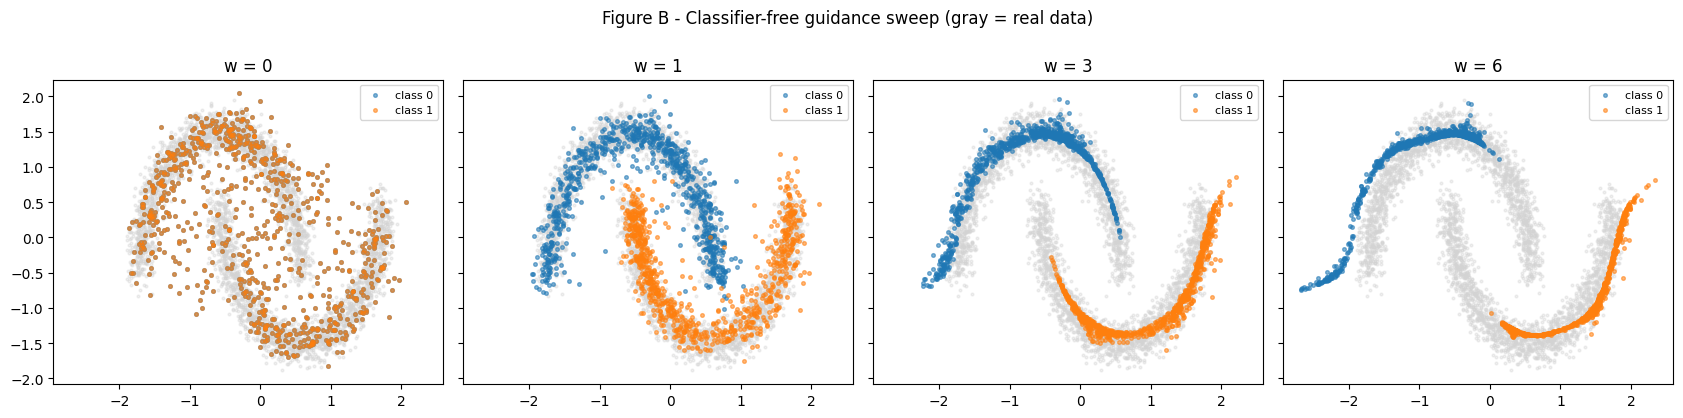

In [11]:
ws = [0, 1, 3, 6]
NS_C = 800
fig, axes = plt.subplots(1, len(ws), figsize=(4.2 * len(ws), 4.3), sharex=True, sharey=True)
for ax, w in zip(axes, ws):
    for c in [0, 1]:
        seed_everything()  # same noise per class across w for comparability
        samp = ddim_sample_cfg(model, NS_C, c, w=float(w), steps=50)
        ax.scatter(samp[:, 0], samp[:, 1], s=7, alpha=0.55, label="class %d" % c)
    ax.scatter(X_np[:, 0], X_np[:, 1], s=4, c="lightgray", alpha=0.35, zorder=0)
    ax.set_title("w = %d" % w)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Figure B - Classifier-free guidance sweep (gray = real data)")
plt.tight_layout()
plt.show()

## Takeaways

- **DDIM** reuses a DDPM-trained network but samples deterministically along a *non-Markovian*
  reverse process, so you can skip timesteps and get good samples in 20-50 steps instead of
  ~200. The cost is paid in network evaluations, which DDIM slashes.
- **Classifier-free guidance** needs only label dropout at train time (one model learns both
  conditional and unconditional predictions). At sampling time,
  `eps = eps_uncond + w * (eps_cond - eps_uncond)` trades diversity for class sharpness as
  `w` increases.
- The two ideas compose cleanly: the CFG sweep above runs on top of the *fast* deterministic
  DDIM sampler.

**Caveat:** this is a 2D pedagogical toy. The qualitative behaviors (fewer DDIM steps,
sharper separation with higher `w`) transfer to real image diffusion, but absolute numbers
(optimal step counts, useful `w` ranges, over-saturation at very high `w`) are
problem-specific and look quite different on high-dimensional data.